In [ ]:
# End-to-End ML Pipeline for Customer Churn Prediction

## Objective

Develop a production-ready machine learning pipeline using Scikit-learn's Pipeline API to predict customer churn.

---

### Dataset
Telco Customer Churn Dataset

---

### Models Used

- Logistic Regression
- Random Forest

---

### Techniques Used

- Data Cleaning
- Feature Engineering
- Pipeline API
- ColumnTransformer
- GridSearchCV
- Model Evaluation
- Joblib Model Export

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
## 1. Load the Dataset

In this section, we load the Telco Customer Churn dataset and inspect its structure to understand the available features and target variable.

In [4]:
# Load the dataset
df = pd.read_csv("Telco Churn.csv")

# Display the first 5 rows
df.head()

,Account_Length,Vmail_Message,Day_Mins,Eve_Mins,Night_Mins,Intl_Mins,CustServ_Calls,Churn,Intl_Plan,Vmail_Plan,...,Day_Charge,Eve_Calls,Eve_Charge,Night_Calls,Night_Charge,Intl_Calls,Intl_Charge,State,Area_Code,Phone
0,128,25,265.1,197.4,244.7,10.0,1,no,no,yes,...,45.07,99,16.78,91,11.01,3,2.70,KS,415,382-4657
1,107,26,161.6,195.5,254.4,13.7,1,no,no,yes,...,27.47,103,16.62,103,11.45,3,3.70,OH,415,371-7191
2,137,0,243.4,121.2,162.6,12.2,0,no,no,no,...,41.38,110,10.30,104,7.32,5,3.29,NJ,415,358-1921
3,84,0,299.4,61.9,196.9,6.6,2,no,yes,no,...,50.90,88,5.26,89,8.86,7,1.78,OH,408,375-9999
4,75,0,166.7,148.3,186.9,10.1,3,no,yes,no,...,28.34,122,12.61,121,8.41,3,2.73,OK,415,330-6626


In [ ]:
## 2. Dataset Overview

Let's examine the size, structure, and data types of the dataset.

In [5]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (3333, 21)

Columns:
['Account_Length', 'Vmail_Message', 'Day_Mins', 'Eve_Mins', 'Night_Mins', 'Intl_Mins', 'CustServ_Calls', 'Churn', 'Intl_Plan', 'Vmail_Plan', 'Day_Calls', 'Day_Charge', 'Eve_Calls', 'Eve_Charge', 'Night_Calls', 'Night_Charge', 'Intl_Calls', 'Intl_Charge', 'State', 'Area_Code', 'Phone']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Account_Length  3333 non-null   int64  
 1   Vmail_Message   3333 non-null   int64  
 2   Day_Mins        3333 non-null   float64
 3   Eve_Mins        3333 non-null   float64
 4   Night_Mins      3333 non-null   float64
 5   Intl_Mins       3333 non-null   float64
 6   CustServ_Calls  3333 non-null   int64  
 7   Churn           3333 non-null   object 
 8   Intl_Plan       3333 non-null   object 
 9   Vmail_Plan      3333 non-null   object 
 10  Day_

In [ ]:
## 3. Statistical Summary

Generate descriptive statistics for numerical and categorical features.

In [6]:
# Numerical statistics
df.describe()

,Account_Length,Vmail_Message,Day_Mins,Eve_Mins,Night_Mins,Intl_Mins,CustServ_Calls,Day_Calls,Day_Charge,Eve_Calls,Eve_Charge,Night_Calls,Night_Charge,Intl_Calls,Intl_Charge,Area_Code
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,8.099010,179.775098,200.980348,200.872037,10.237294,1.562856,100.435644,30.562307,100.114311,17.083540,100.107711,9.039325,4.479448,2.764581,437.182418
std,39.822106,13.688365,54.467389,50.713844,50.573847,2.791840,1.315491,20.069084,9.259435,19.922625,4.310668,19.568609,2.275873,2.461214,0.753773,42.371290
min,1.000000,0.000000,0.000000,0.000000,23.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.000000,1.040000,0.000000,0.000000,408.000000
25%,74.000000,0.000000,143.700000,166.600000,167.000000,8.500000,1.000000,87.000000,24.430000,87.000000,14.160000,87.000000,7.520000,3.000000,2.300000,408.000000
50%,101.000000,0.000000,179.400000,201.400000,201.200000,10.300000,1.000000,101.000000,30.500000,100.000000,17.120000,100.000000,9.050000,4.000000,2.780000,415.000000
75%,127.000000,20.000000,216.400000,235.300000,235.300000,12.100000,2.000000,114.000000,36.790000,114.000000,20.000000,113.000000,10.590000,6.000000,3.270000,510.000000
max,243.000000,51.000000,350.800000,363.700000,395.000000,20.000000,9.000000,165.000000,59.640000,170.000000,30.910000,175.000000,17.770000,20.000000,5.400000,510.000000


In [7]:
# Statistics for categorical columns
df.describe(include="object")

,Churn,Intl_Plan,Vmail_Plan,State,Phone
count,3333,3333,3333,3333,3333
unique,2,2,2,51,3333
top,no,no,no,WV,382-4657
freq,2850,3010,2411,106,1


In [ ]:
## 4. Missing Values

Check whether the dataset contains missing values.

In [8]:
# Missing values
missing_values = df.isnull().sum()

print(missing_values)

Account_Length    0
Vmail_Message     0
Day_Mins          0
Eve_Mins          0
Night_Mins        0
Intl_Mins         0
CustServ_Calls    0
Churn             0
Intl_Plan         0
Vmail_Plan        0
Day_Calls         0
Day_Charge        0
Eve_Calls         0
Eve_Charge        0
Night_Calls       0
Night_Charge      0
Intl_Calls        0
Intl_Charge       0
State             0
Area_Code         0
Phone             0
dtype: int64


In [ ]:
## 5. Duplicate Records

Check whether duplicate records are present in the dataset.

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
## 6. Target Variable Distribution

Let's examine how many customers churned versus stayed.

In [10]:
df["Churn"].value_counts()

Churn
no     2850
yes     483
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True) * 100

Churn
no     85.508551
yes    14.491449
Name: proportion, dtype: float64

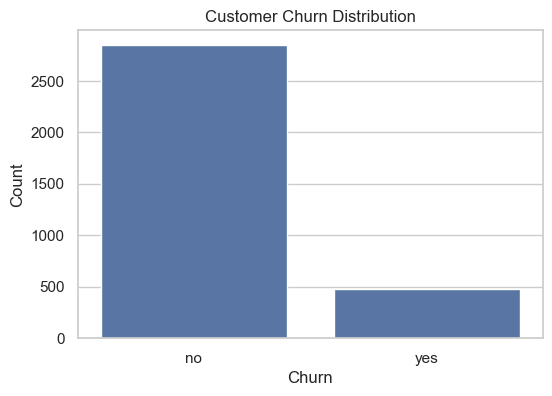

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [13]:
print(df.dtypes)

Account_Length      int64
Vmail_Message       int64
Day_Mins          float64
Eve_Mins          float64
Night_Mins        float64
Intl_Mins         float64
CustServ_Calls      int64
Churn              object
Intl_Plan          object
Vmail_Plan         object
Day_Calls           int64
Day_Charge        float64
Eve_Calls           int64
Eve_Charge        float64
Night_Calls         int64
Night_Charge      float64
Intl_Calls          int64
Intl_Charge       float64
State              object
Area_Code           int64
Phone              object
dtype: object


In [14]:
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].unique())


Churn
['no' 'yes']

Intl_Plan
['no' 'yes']

Vmail_Plan
['yes' 'no']

State
['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'LA' 'WV' 'IN' 'RI' 'IA' 'MT' 'NY'
 'ID' 'VT' 'VA' 'TX' 'FL' 'CO' 'AZ' 'SC' 'NE' 'WY' 'HI' 'IL' 'NH' 'GA'
 'AK' 'MD' 'AR' 'WI' 'OR' 'MI' 'DE' 'UT' 'CA' 'MN' 'SD' 'NC' 'WA' 'NM'
 'NV' 'DC' 'KY' 'ME' 'MS' 'TN' 'PA' 'CT' 'ND']

Phone
['382-4657' '371-7191' '358-1921' ... '328-8230' '364-6381' '400-4344']


In [ ]:
## 9. Separate Features and Target Variable

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [30]:
# Remove extra spaces and convert to lowercase
df["Churn"] = df["Churn"].str.strip().str.lower()

# Map to numerical values
y = df["Churn"].map({
    "no": 0,
    "yes": 1
})

In [20]:
# Numerical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['Account_Length', 'Vmail_Message', 'Day_Mins', 'Eve_Mins', 'Night_Mins',
       'Intl_Mins', 'CustServ_Calls', 'Day_Calls', 'Day_Charge', 'Eve_Calls',
       'Eve_Charge', 'Night_Calls', 'Night_Charge', 'Intl_Calls',
       'Intl_Charge', 'Area_Code'],
      dtype='object')

Categorical Features:
Index(['Intl_Plan', 'Vmail_Plan', 'State', 'Phone'], dtype='object')


In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [22]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
## 10. Create a Preprocessing Pipeline

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [25]:
print(df["Churn"].unique())

['no' 'yes']


In [27]:
print(y.isnull().sum())

3333


In [34]:
# Clean the Churn column
df["Churn"] = df["Churn"].str.strip().str.lower()

In [35]:
# Recreate X and y
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "no": 0,
    "yes": 1
})

In [36]:
print(y.unique())

[0 1]


In [37]:
print(y.isnull().sum())

0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Set: (2666, 20)
Testing Set: (667, 20)
Training Labels: (2666,)
Testing Labels: (667,)


In [ ]:
## 12. Logistic Regression Pipeline

In this section, we combine the preprocessing pipeline with a Logistic Regression classifier to create a complete machine learning pipeline.

In [40]:
# Create Logistic Regression Pipeline
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

In [41]:
# Train Logistic Regression
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
# Predict on test data
y_pred_lr = logistic_pipeline.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.8590704647676162


In [44]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       570
           1       0.53      0.25      0.34        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667



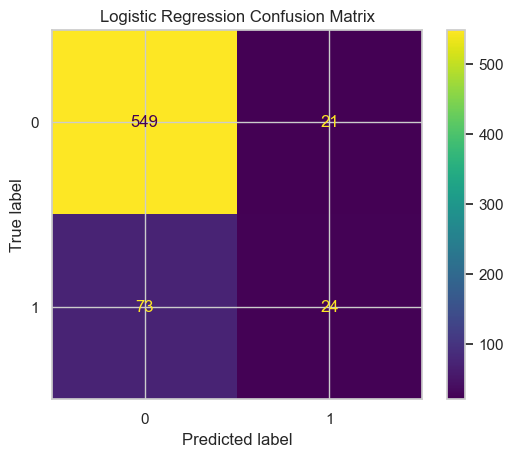

In [45]:
cm = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
## 13. Random Forest Pipeline

Build and evaluate a Random Forest classifier using the same preprocessing pipeline.

In [46]:
# Create Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [47]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
y_pred_rf = rf_pipeline.predict(X_test)

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8995502248875562


In [50]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       570
           1       0.92      0.34      0.50        97

    accuracy                           0.90       667
   macro avg       0.91      0.67      0.72       667
weighted avg       0.90      0.90      0.88       667



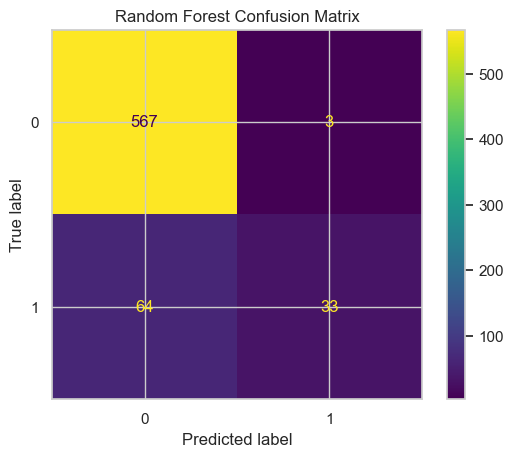

In [51]:
cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
## 14. Model Comparison

Compare the performance of Logistic Regression and Random Forest using accuracy.

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.85907
1,Random Forest,0.89955


In [ ]:
## 15. Hyperparameter Tuning - Logistic Regression

Use GridSearchCV to find the optimal hyperparameters for the Logistic Regression model.

In [53]:
# Logistic Regression Pipeline
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

In [54]:
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear", "lbfgs"]
}

In [55]:
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [56]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'lbfgs'}


In [57]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'lbfgs'}


In [58]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test)

print(classification_report(y_test, y_pred_best_lr))

print("Accuracy:", accuracy_score(y_test, y_pred_best_lr))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       570
           1       0.53      0.25      0.34        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667

Accuracy: 0.8590704647676162


In [ ]:
## 16. Hyperparameter Tuning - Random Forest

Optimize the Random Forest classifier using GridSearchCV.

In [59]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [60]:
param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

In [61]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [62]:
print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [63]:
print("Best Cross Validation Score:")
print(grid_rf.best_score_)

Best Cross Validation Score:
0.9069790810267653


In [64]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best_rf))

print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95       570
           1       0.97      0.36      0.53        97

    accuracy                           0.91       667
   macro avg       0.94      0.68      0.74       667
weighted avg       0.91      0.91      0.89       667

Accuracy: 0.9055472263868066


In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_lr),
        accuracy_score(y_test, y_pred_best_rf)
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,Tuned Random Forest,0.905547
1,Random Forest,0.899550
0,Logistic Regression,0.859070
2,Tuned Logistic Regression,0.859070


In [66]:
joblib.dump(best_rf, "churn_pipeline.joblib")

['churn_pipeline.joblib']

In [68]:
loaded_pipeline = joblib.load("churn_pipeline.joblib")

sample_prediction = loaded_pipeline.predict(X_test.iloc[:5])

print(sample_prediction)

[1 0 0 0 0]


In [70]:
results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": sample_prediction
})

results["Actual"] = results["Actual"].map({0: "No Churn", 1: "Churn"})
results["Predicted"] = results["Predicted"].map({0: "No Churn", 1: "Churn"})

results

,Actual,Predicted
0,Churn,Churn
1,No Churn,No Churn
2,No Churn,No Churn
3,No Churn,No Churn
4,No Churn,No Churn


In [71]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_lr),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    "Precision": [
        classification_report(y_test, y_pred_lr, output_dict=True)["weighted avg"]["precision"],
        classification_report(y_test, y_pred_rf, output_dict=True)["weighted avg"]["precision"],
        classification_report(y_test, y_pred_best_lr, output_dict=True)["weighted avg"]["precision"],
        classification_report(y_test, y_pred_best_rf, output_dict=True)["weighted avg"]["precision"]
    ],
    "Recall": [
        classification_report(y_test, y_pred_lr, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_pred_best_lr, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_pred_best_rf, output_dict=True)["weighted avg"]["recall"]
    ],
    "F1-Score": [
        classification_report(y_test, y_pred_lr, output_dict=True)["weighted avg"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["weighted avg"]["f1-score"],
        classification_report(y_test, y_pred_best_lr, output_dict=True)["weighted avg"]["f1-score"],
        classification_report(y_test, y_pred_best_rf, output_dict=True)["weighted avg"]["f1-score"]
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
3,Tuned Random Forest,0.905547,0.911993,0.905547,0.886286
1,Random Forest,0.899550,0.901205,0.899550,0.879066
0,Logistic Regression,0.859070,0.831838,0.859070,0.836340
2,Tuned Logistic Regression,0.859070,0.831838,0.859070,0.836340
